# Variational Quantum Eigensolver (VQE) for the Hydrogen Molecule

This tutorial demonstrates how to implement the Variational Quantum Eigensolver (VQE) algorithm to find the ground state energy of the hydrogen molecule (H₂). We use several quantum computing frameworks: OpenFermion for generating molecular Hamiltonians, Qamomile for quantum circuit construction, and Qiskit for quantum simulation.

The workflow is as follows:
1. Convert the molecular Hamiltonian to qubit operators
2. Create a parametrized quantum circuit (ansatz)
3. Implement VQE optimization
4. Analyze the energy landscape across different atomic distances

We show how to solve quantum chemistry problems using quantum computing, focusing on finding the minimum-energy structure of the H₂ molecule.

In [1]:
# Required packages can be installed with the following command
# !pip install openfermion pyscf openfermionpyscf

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import openfermion.chem as of_chem
import openfermion.transforms as of_trans
import openfermionpyscf as of_pyscf
from qiskit_aer.primitives import EstimatorV2
from scipy.optimize import minimize

import qamomile.circuit as qmc
import qamomile.observable as qm_o
from qamomile.circuit.algorithm.basic import ry_layer, rz_layer
from qamomile.qiskit import QiskitTranspiler
from qamomile.qiskit.transpiler import QiskitExecutor

## Creating the Hamiltonian of the Hydrogen Molecule

In [3]:
basis = "sto-3g"
multiplicity = 1
charge = 0
distance = 0.977
geometry = [["H", [0, 0, 0]], ["H", [0, 0, distance]]]
description = "tmp"
molecule = of_chem.MolecularData(geometry, basis, multiplicity, charge, description)
molecule = of_pyscf.run_pyscf(molecule, run_scf=True, run_fci=True)
n_qubit = molecule.n_qubits
n_electron = molecule.n_electrons
fermionic_hamiltonian = of_trans.get_fermion_operator(molecule.get_molecular_hamiltonian())
jw_hamiltonian = of_trans.jordan_wigner(fermionic_hamiltonian)

## Converting to a Qamomile Hamiltonian

In this section, we convert the OpenFermion Hamiltonian to the Qamomile format. After applying the Jordan–Wigner transformation to convert fermionic operators to qubit operators, we use custom conversion functions to create a Hamiltonian representation compatible with Qamomile.

In [4]:
def operator_to_qamomile(operators: tuple[tuple[int, str], ...]) -> qm_o.Hamiltonian:
    pauli = {"X": qm_o.X, "Y": qm_o.Y, "Z": qm_o.Z}
    H = qm_o.Hamiltonian()
    H.constant = 1.0
    for ope in operators:
        H = H * pauli[ope[1]](ope[0])
    return H

def openfermion_to_qamomile(of_h) -> qm_o.Hamiltonian:
    H = qm_o.Hamiltonian()
    for k, v in of_h.terms.items():
        if len(k) == 0:
            H.constant += v
        else:
            H += operator_to_qamomile(k) * v
    return H

hamiltonian = openfermion_to_qamomile(jw_hamiltonian)

## Creating the VQE Ansatz

In this section, we create an EfficientSU2 ansatz for the VQE algorithm using the `@qkernel` decorator. An ansatz is a parametrized quantum circuit that prepares a trial wavefunction. We build it by combining `ry_layer`, `rz_layer`, and a linear CX entangling layer, and finally compute the expectation value of the Hamiltonian using `expval`.

In [5]:
@qmc.qkernel
def cx_entangling_layer(q: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    """Linear CX entangling layer."""
    n = q.shape[0]
    for i in qmc.range(n - 1):
        q[i], q[i + 1] = qmc.cx(q[i], q[i + 1])
    return q


@qmc.qkernel
def vqe_ansatz(
    n: qmc.UInt,
    reps: qmc.UInt,
    thetas: qmc.Vector[qmc.Float],
    H: qmc.Observable,
) -> qmc.Float:
    q = qmc.qubit_array(n, name="q")
    for r in qmc.range(reps):
        base = r * 2 * n
        q = ry_layer(q, thetas, base)
        q = rz_layer(q, thetas, base + n)
        q = cx_entangling_layer(q)
    # Final rotation layer
    final_base = reps * 2 * n
    q = ry_layer(q, thetas, final_base)
    q = rz_layer(q, thetas, final_base + n)
    return qmc.expval(q, H)

## Running VQE with Qiskit

In this section, we use `QiskitTranspiler` to transpile the VQE kernel and execute it on the Qiskit Aer simulator. The transpiler automatically handles the expectation value computation via `expval`, so the user only needs to implement the optimization loop. Of course, other quantum computing frameworks can be used as well.

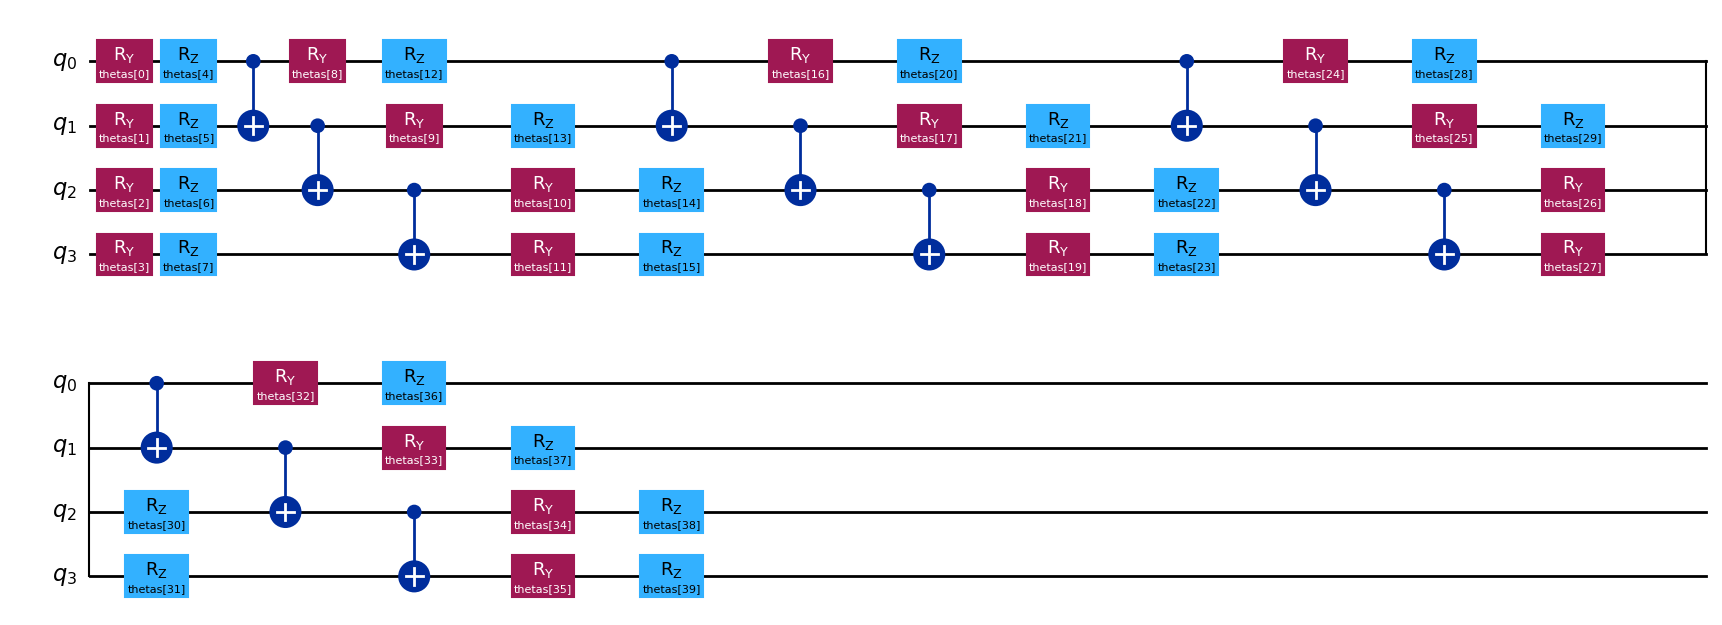

In [6]:
transpiler = QiskitTranspiler()
reps = 4

executable = transpiler.transpile(
    vqe_ansatz,
    bindings={"n": n_qubit, "reps": reps, "H": hamiltonian},
    parameters=["thetas"],
)

# Transpiled quantum circuit
executable.quantum_circuit.draw("mpl")

In [7]:
cost_history = []
executor = QiskitExecutor(estimator=EstimatorV2())


def cost_fn(param_values):
    job = executable.run(executor, bindings={"thetas": list(param_values)})
    return job.result()


def cost_callback(param_values):
    cost_history.append(cost_fn(param_values))


num_params = len(executable.parameter_names)
initial_params = np.random.uniform(0, np.pi, num_params)

# Run VQE optimization
result = minimize(
    cost_fn,
    initial_params,
    method="BFGS",
    options={"disp": True, "maxiter": 50, "gtol": 1e-6},
    callback=cost_callback,
)
print(result)

         Current function value: -1.105869
         Iterations: 50
         Function evaluations: 2132
         Gradient evaluations: 52
  message: Maximum number of iterations has been exceeded.
  success: False
   status: 1
      fun: -1.1058694845651038
        x: [ 2.584e+00  1.433e+00 ...  2.786e+00  2.265e+00]
      nit: 50
      jac: [ 2.046e-04 -3.181e-04 ... -1.142e-04 -1.161e-04]
 hess_inv: [[ 2.278e+01 -5.699e-01 ...  1.755e+00  1.985e+00]
            [-5.699e-01  1.178e+00 ...  1.915e-01  1.270e-01]
            ...
            [ 1.755e+00  1.915e-01 ...  1.768e+00  7.719e-01]
            [ 1.985e+00  1.270e-01 ...  7.719e-01  1.904e+00]]
     nfev: 2132
     njev: 52


/Users/masakishiraishi/projects/jij/Qamomile/.venv/lib/python3.12/site-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


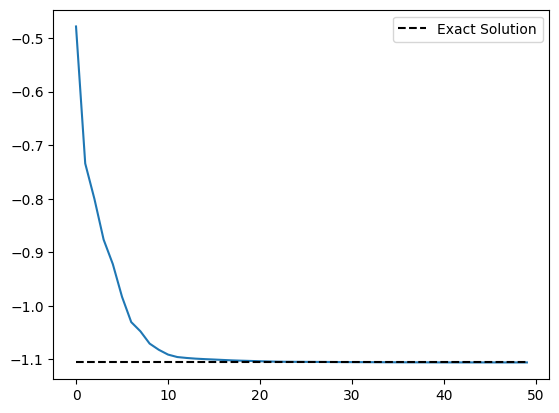

In [8]:
plt.plot(cost_history)
plt.plot(
    range(len(cost_history)),
    [molecule.fci_energy] * len(cost_history),
    linestyle="dashed",
    color="black",
    label="Exact Solution",
)
plt.legend()
plt.show()

## Changing the Distance Between Atoms

In [9]:
def hydrogen_molecule(bond_length):
    basis = "sto-3g"
    multiplicity = 1
    charge = 0
    geometry = [["H", [0, 0, 0]], ["H", [0, 0, bond_length]]]
    description = "tmp"
    molecule = of_chem.MolecularData(geometry, basis, multiplicity, charge, description)
    molecule = of_pyscf.run_pyscf(molecule, run_scf=True, run_fci=True)
    fermionic_hamiltonian = of_trans.get_fermion_operator(
        molecule.get_molecular_hamiltonian()
    )
    jw_hamiltonian = of_trans.jordan_wigner(fermionic_hamiltonian)
    return openfermion_to_qamomile(jw_hamiltonian), molecule.fci_energy

bond_lengths = np.linspace(0.2, 1.5, 15)
energies = []
for bond_length in bond_lengths:
    hamiltonian, fci_energy = hydrogen_molecule(bond_length)

    executable = transpiler.transpile(
        vqe_ansatz,
        bindings={"n": hamiltonian.num_qubits, "reps": reps, "H": hamiltonian},
        parameters=["thetas"],
    )

    num_params = len(executable.parameter_names)
    initial_params = np.random.uniform(0, np.pi, num_params)
    result = minimize(
        cost_fn,
        initial_params,
        method="BFGS",
        options={"maxiter": 50, "gtol": 1e-6},
    )

    energies.append(result.fun)

    print("distance: ", bond_length, "energy: ", result.fun, "fci_energy: ", fci_energy)

distance:  0.2 energy:  0.15773863155313728 fci_energy:  0.15748213479836526


distance:  0.29285714285714287 energy:  -0.567916622081087 fci_energy:  -0.5679447209710013


distance:  0.38571428571428573 energy:  -0.8820324756051116 fci_energy:  -0.8833596636183383


distance:  0.4785714285714286 energy:  -1.0327862260035898 fci_energy:  -1.0336011797110967


distance:  0.5714285714285714 energy:  -1.1042068617079177 fci_energy:  -1.1042094222435166


...

distance:  1.1285714285714286 energy:  -1.0727318103222063 fci_energy:  -1.0727578805453502


distance:  1.2214285714285713 energy:  -1.0520050589995704 fci_energy:  -1.052008162170845


distance:  1.3142857142857143 energy:  -1.0322072900323618 fci_energy:  -1.0322400306247084


distance:  1.4071428571428573 energy:  -1.0141335981541746 fci_energy:  -1.0141470586695496


distance:  1.5 energy:  -0.9966618570761571 fci_energy:  -0.9981493534714101


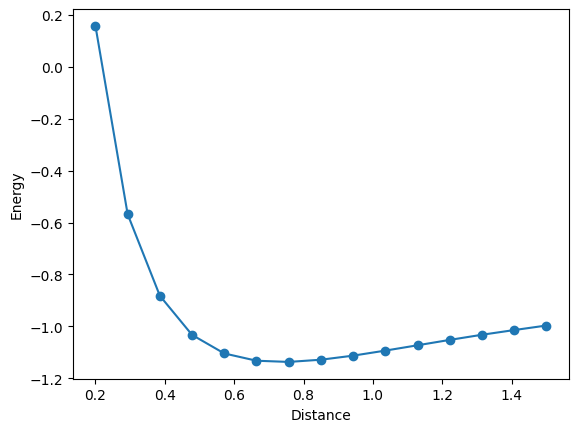

In [10]:
plt.plot(bond_lengths, energies, "-o")
plt.xlabel("Distance")
plt.ylabel("Energy")
plt.show()